In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("oil.csv")
df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [5]:
df.describe()

,dcoilwtico
count,1175.000000
mean,67.714366
std,25.630476
min,26.190000
25%,46.405000
50%,53.190000
75%,95.660000
max,110.620000


In [7]:
df.shape

(1218, 2)

In [8]:
df.columns

Index(['date', 'dcoilwtico'], dtype='object')

In [9]:
df.isnull().sum()

,0
date,0
dcoilwtico,43


In [13]:
df.dropna(inplace=True)

In [14]:
df.isna().sum()

,0
date,0
dcoilwtico,0


In [16]:
df['date'] = pd.to_datetime(df['date'])

In [18]:
df.set_index('date', inplace=True)

In [26]:
df.rename(columns={'dcoilwtico': 'oilprice'}, inplace=True)
print(df.columns)

Index(['oilprice'], dtype='object')


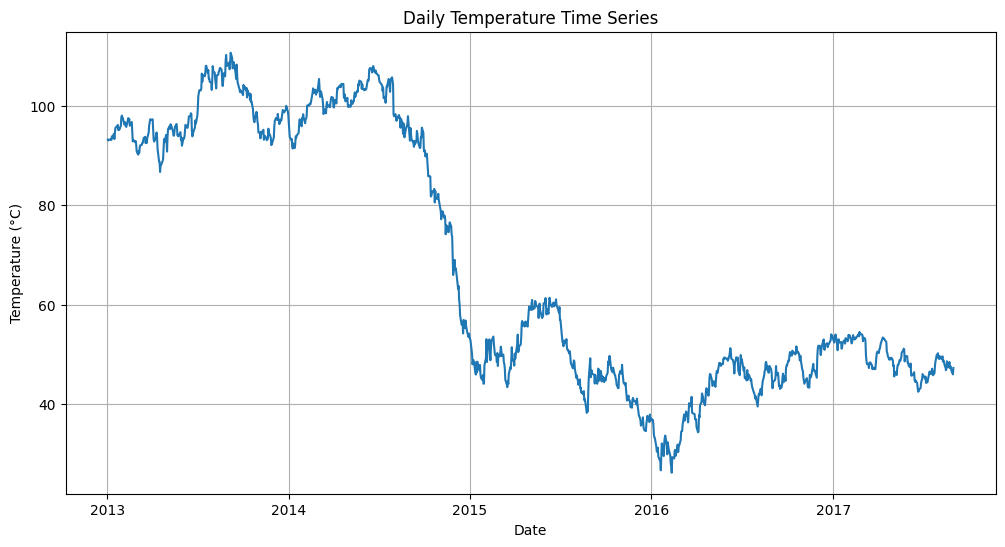

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['oilprice'])
plt.title('Daily Temperature Time Series')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

In [29]:
result = adfuller(df['oilprice'].dropna())

In [30]:
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of Lags Used:", result[2])
print("Number of Observations:", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.8771776701964072
p-value: 0.7953952087184238
Number of Lags Used: 1
Number of Observations: 1173

Critical Values:
1%: -3.435937099783359
5%: -2.864007125872554
10%: -2.5680835504811657


In [31]:
df['oilprice_diff'] = df['oilprice'].diff()

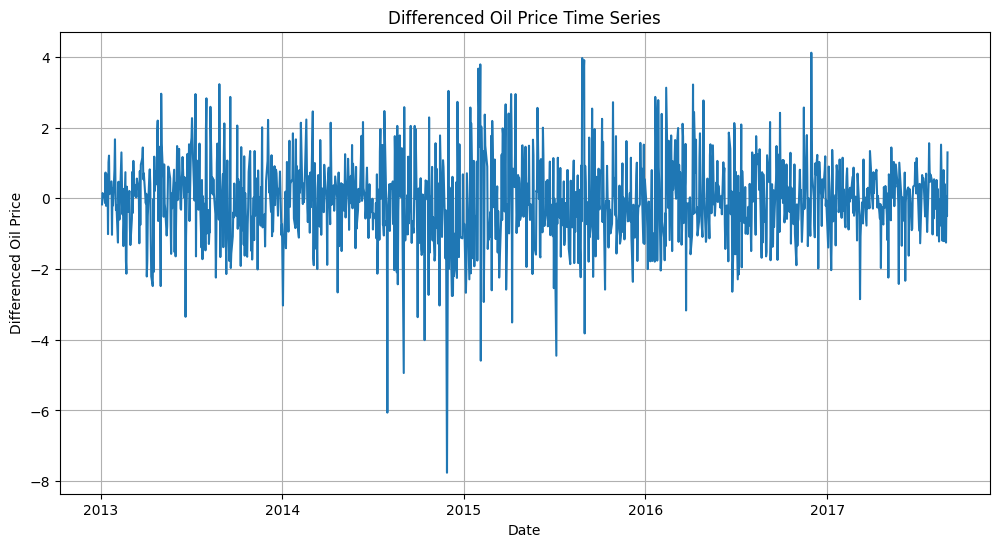

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df['oilprice_diff'])
plt.title("Differenced Oil Price Time Series")
plt.xlabel("Date")
plt.ylabel("Differenced Oil Price")
plt.grid(True)
plt.show()

In [35]:
oilprice_diff = df['oilprice_diff'].dropna()

result = adfuller(oilprice_diff)

In [36]:

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -36.396148176858176
p-value: 0.0


<Figure size 1000x500 with 0 Axes>

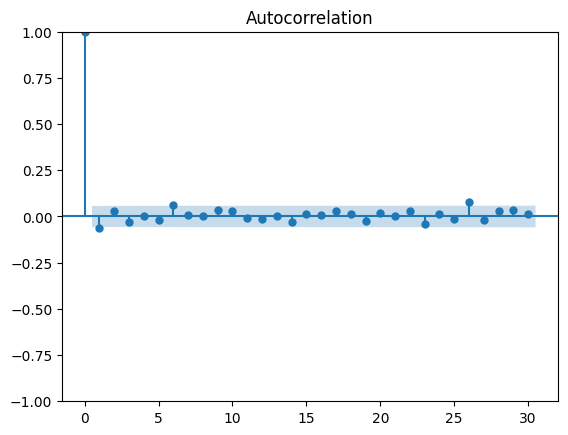

In [37]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(df['oilprice_diff'].dropna(), lags=30)
plt.show()

<Figure size 1000x500 with 0 Axes>

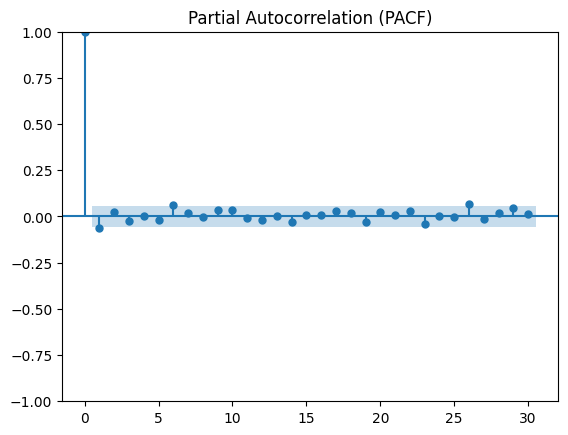

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_pacf(df['oilprice_diff'].dropna(), lags=30)
plt.title("Partial Autocorrelation (PACF)")
plt.show()

In [39]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['oilprice'], order=(0,1,0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [40]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               oilprice   No. Observations:                 1175
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1904.498
Date:                Tue, 30 Jun 2026   AIC                           3810.996
Time:                        20:08:33   BIC                           3816.064
Sample:                             0   HQIC                          3812.908
                               - 1175                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.5017      0.042     35.476      0.000       1.419       1.585
Ljung-Box (L1) (Q):                   4.53   Jarque-Bera (JB):               265.77
Prob(Q):                              0.03   Pr

In [41]:
forecast = model_fit.forecast(steps=30)

print(forecast)

1175    47.26
1176    47.26
1177    47.26
1178    47.26
1179    47.26
1180    47.26
1181    47.26
1182    47.26
1183    47.26
1184    47.26
1185    47.26
1186    47.26
1187    47.26
1188    47.26
1189    47.26
1190    47.26
1191    47.26
1192    47.26
1193    47.26
1194    47.26
1195    47.26
1196    47.26
1197    47.26
1198    47.26
1199    47.26
1200    47.26
1201    47.26
1202    47.26
1203    47.26
1204    47.26
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


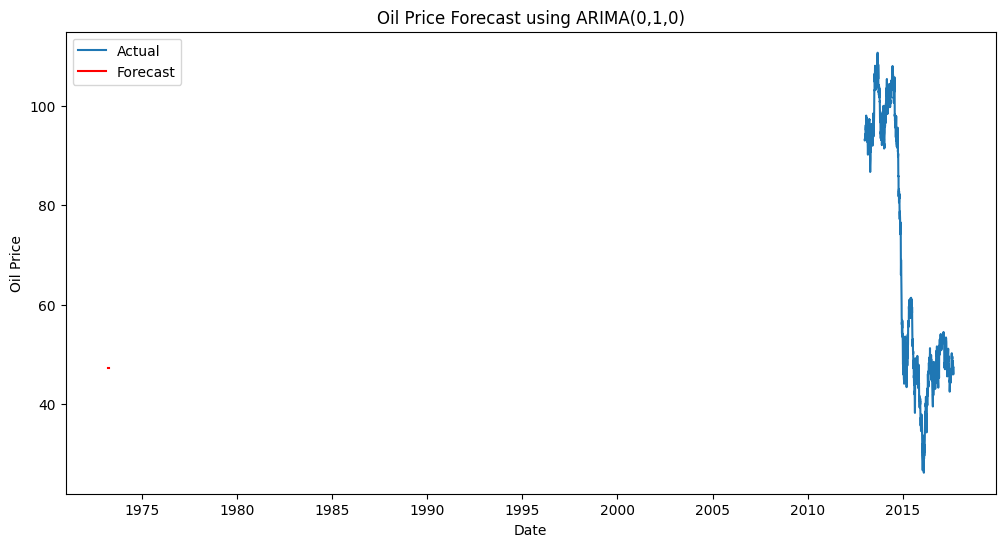

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['oilprice'], label='Actual')
plt.plot(forecast.index, forecast, color='red', label='Forecast')
plt.title('Oil Price Forecast using ARIMA(0,1,0)')
plt.xlabel('Date')
plt.ylabel('Oil Price')
plt.legend()
plt.show()

In [43]:
train_size = int(len(df) * 0.8)

train = df['oilprice'][:train_size]
test = df['oilprice'][train_size:]

In [94]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,2))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [95]:
predictions = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 5.580029800994017
MAE: 4.806880569782175


In [97]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, predictions)

print("MAPE:", mape)
print("MAPE (%):", mape * 100)

MAPE: 0.09468806358741842
MAPE (%): 9.468806358741842


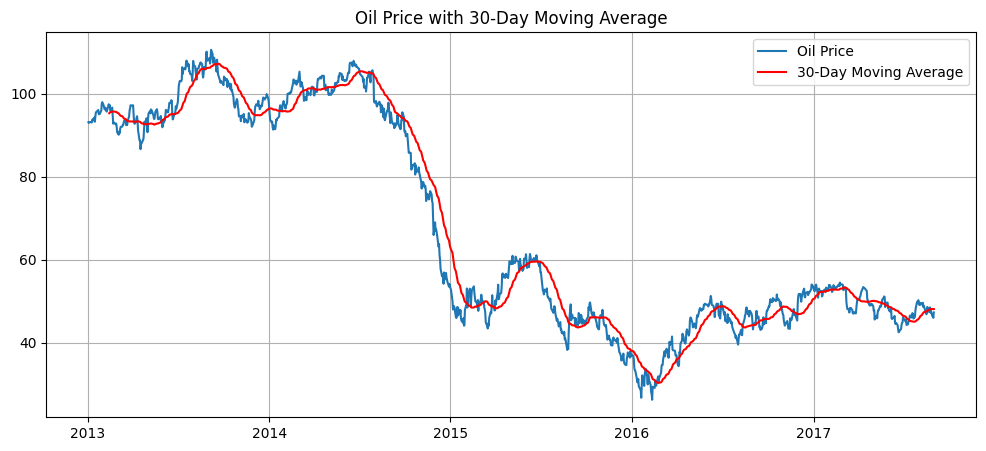

In [98]:
df['MA30'] = df['oilprice'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df['oilprice'], label='Oil Price')
plt.plot(df['MA30'], color='red', label='30-Day Moving Average')
plt.title("Oil Price with 30-Day Moving Average")
plt.legend()
plt.grid(True)
plt.show()

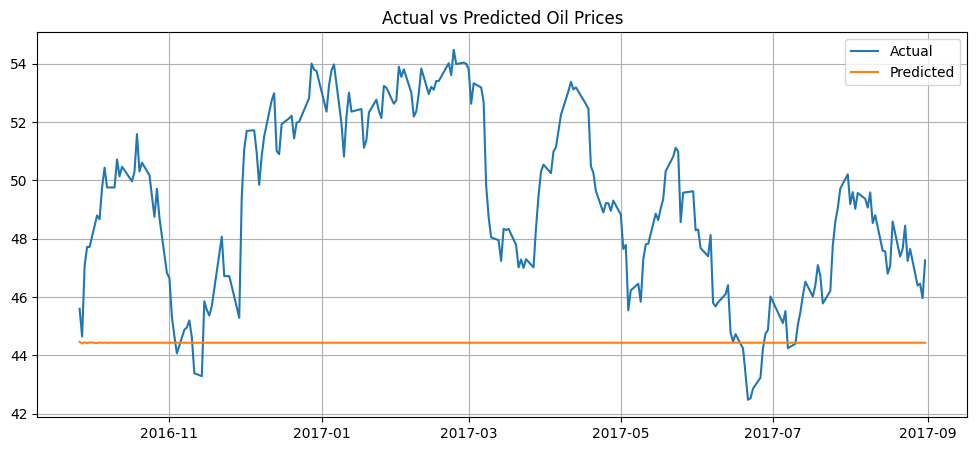